In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [63]:
df_customers = pd.read_csv(r'Olist_dataset\olist_customers_dataset.csv.zip')
df_geo = pd.read_csv(r'Olist_dataset\olist_geolocation_dataset.csv.zip')
df_order_payments = pd.read_csv(r'Olist_dataset\olist_order_payments_dataset.csv.zip')
df_order_reviews = pd.read_csv(r'Olist_dataset\olist_order_reviews_dataset.csv.zip')
df_orders_dataset = pd.read_csv(r'Olist_dataset\olist_orders_dataset.csv.zip')
df_products_dataset = pd.read_csv(r'Olist_dataset\olist_products_dataset.csv.zip')
df_sellers_dataset = pd.read_csv(r'Olist_dataset\olist_sellers_dataset.csv')
df_product_category_name_translation = pd.read_csv(r'Olist_dataset\product_category_name_translation.csv')
df_items = pd.read_csv(r'Olist_dataset\olist_order_items_dataset.csv.zip')

### Соединим несоклько таблиц в один датасет для более удобной работы

In [64]:
df = df_orders_dataset.merge(
    df_customers,
    on="customer_id",
    how="left"
)

In [65]:
df = df.merge(
    df_items,
    on="order_id",
    how="left"
)

In [66]:
df = df.merge(
    df_products_dataset,
    on="product_id",
    how="left"
)


In [67]:
df = df.merge(
    df_sellers_dataset,
    on="seller_id",
    how="left"
)

In [68]:
df_payments_agg = df_order_payments.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_installments": "max"
}).reset_index()

In [69]:
df = df.merge(
    df_payments_agg,
    on="order_id",
    how="left"
)


In [70]:
df = df.merge(
    df_order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)


In [71]:
df = df.merge(
    df_product_category_name_translation,
    on="product_category_name",
    how="left"
)

In [72]:
df.rename(columns={"product_category_name_english": "category"}, inplace=True)

print(df.shape)
df.head()

(114092, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,review_score,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0,4.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0,4.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0,5.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0,5.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0,5.0,stationery


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  object 
 1   customer_id                    114092 non-null  object 
 2   order_status                   114092 non-null  object 
 3   order_purchase_timestamp       114092 non-null  object 
 4   order_approved_at              113930 non-null  object 
 5   order_delivered_carrier_date   112112 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  114092 non-null  object 
 8   customer_unique_id             114092 non-null  object 
 9   customer_zip_code_prefix       114092 non-null  int64  
 10  customer_city                  114092 non-null  object 
 11  customer_state                 114092 non-null  object 
 12  order_item_id                 

In [74]:
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0]

order_delivered_customer_date    0.028512
category                         0.021158
product_name_lenght              0.020948
product_category_name            0.020948
product_description_lenght       0.020948
product_photos_qty               0.020948
order_delivered_carrier_date     0.017354
review_score                     0.008423
product_weight_g                 0.006977
product_height_cm                0.006977
product_length_cm                0.006977
product_width_cm                 0.006977
seller_state                     0.006819
product_id                       0.006819
seller_id                        0.006819
shipping_limit_date              0.006819
price                            0.006819
seller_city                      0.006819
order_item_id                    0.006819
freight_value                    0.006819
seller_zip_code_prefix           0.006819
order_approved_at                0.001420
payment_installments             0.000026
payment_value                    0

#### Создадим новые информативные признаки
- временные признаки (год, месяц, день недели покупки)
- логистические метрики (delivery_time, delay, carrier_time)
- характеристики товара (объём)
- итоговая стоимость позиции (item_total)

### Заполним пропуски 
- категориальные признаки значением "unknown"
- текстовые и количественные характеристики товаров нулями
- числовые признаки (размеры и вес товаров) с использованием медианных значений внутри категории
- редкие пропуски в цене и доставке медианой для сохранения распределения

In [75]:
df["is_delivered"] = df["order_delivered_customer_date"].notnull().astype(int)
df["carrier_missing"] = df["order_delivered_carrier_date"].isnull().astype(int)
df["product_category_name"] = df["product_category_name"].fillna("unknown")
df["category"] = df["category"].fillna("unknown")
df["product_name_lenght"] = df["product_name_lenght"].fillna(0)
df["product_description_lenght"] = df["product_description_lenght"].fillna(0)
df["product_photos_qty"] = df["product_photos_qty"].fillna(0)

In [76]:
for col in ["product_weight_g", "product_height_cm", "product_length_cm", "product_width_cm"]:
    df[col] = df.groupby("category")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [77]:
df = df[df["seller_id"].notnull()]
df["seller_state"] = df["seller_state"].fillna("unknown")
df["seller_city"] = df["seller_city"].fillna("unknown")

In [78]:
df["price"] = df["price"].fillna(df["price"].median())
df["freight_value"] = df["freight_value"].fillna(df["freight_value"].median())

In [79]:
df["approval_missing"] = df["order_approved_at"].isnull().astype(int)

In [80]:
df["payment_value"] = df["payment_value"].fillna(0)
df["payment_installments"] = df["payment_installments"].fillna(1)

In [92]:
df["purchase_year"] = df["order_purchase_timestamp"].dt.year
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.day_name()

df["product_volume_cm3"] = (
    df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]
)

df["item_total"] = df["price"] + df["freight_value"]

In [81]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_c

In [82]:
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1203
order_delivered_customer_date    2475
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
seller_zip_c

In [83]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [87]:
df["approval_time"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600  

df["carrier_time"] = (
    df["order_delivered_carrier_date"] - df["order_purchase_timestamp"]
).dt.days

df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["delay"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

In [139]:
df[['order_delivered_customer_date', 'order_estimated_delivery_date']]

,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-10 21:25:13,2017-10-18
1,2018-08-07 15:27:45,2018-08-13
2,2018-08-17 18:06:29,2018-09-04
3,2017-12-02 00:28:42,2017-12-15
4,2018-02-16 18:17:02,2018-02-26
...,...,...
114087,2018-02-28 17:37:56,2018-03-02
114088,2017-09-21 11:24:17,2017-09-27
114089,2018-01-25 23:32:54,2018-02-15
114090,2018-01-25 23:32:54,2018-02-15


In [88]:
df[["delivery_time", "delay"]].isna().sum()

delivery_time    2475
delay            2475
dtype: int64

In [94]:
missing = (
    df.isna().mean()
      .sort_values(ascending=False)
      .rename("missing_share")
      .to_frame()
)

display(missing[missing["missing_share"] > 0])

,missing_share
order_delivered_customer_date,0.021842
delay,0.021842
delivery_time,0.021842
order_delivered_carrier_date,0.010617
carrier_time,0.010617
review_score,0.008313
order_approved_at,0.000132
approval_time,0.000132


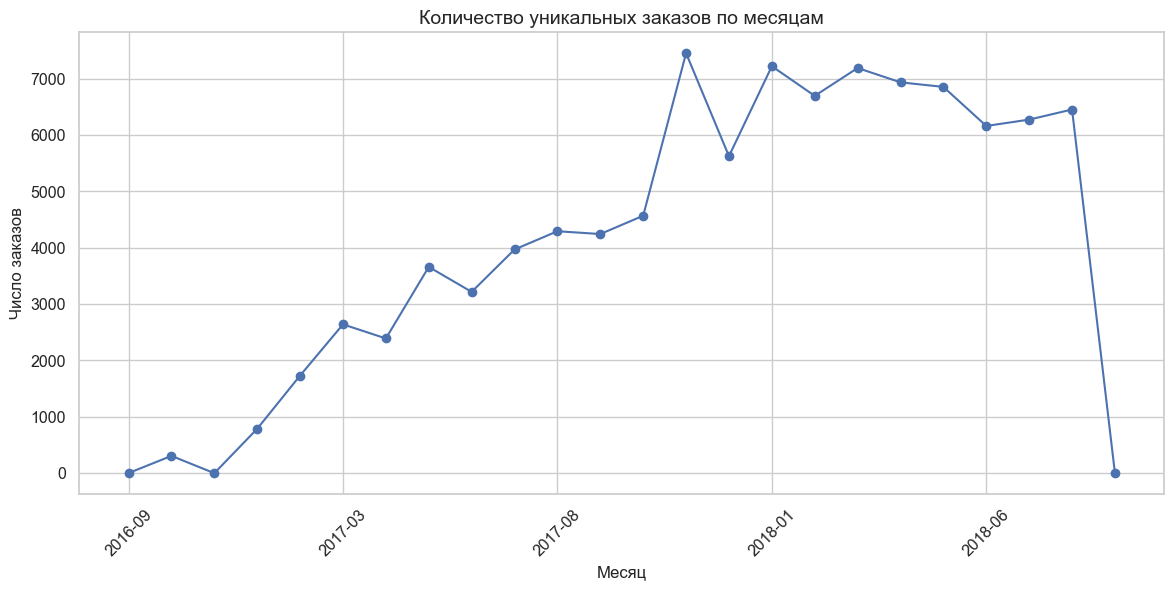

In [95]:
orders_by_month = (
    df.groupby("purchase_month")["order_id"]
      .nunique()
      .sort_index()
)

plt.figure(figsize=(14, 6))
orders_by_month.plot(marker="o")
plt.title("Количество уникальных заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Число заказов")
plt.xticks(rotation=45)
plt.show()

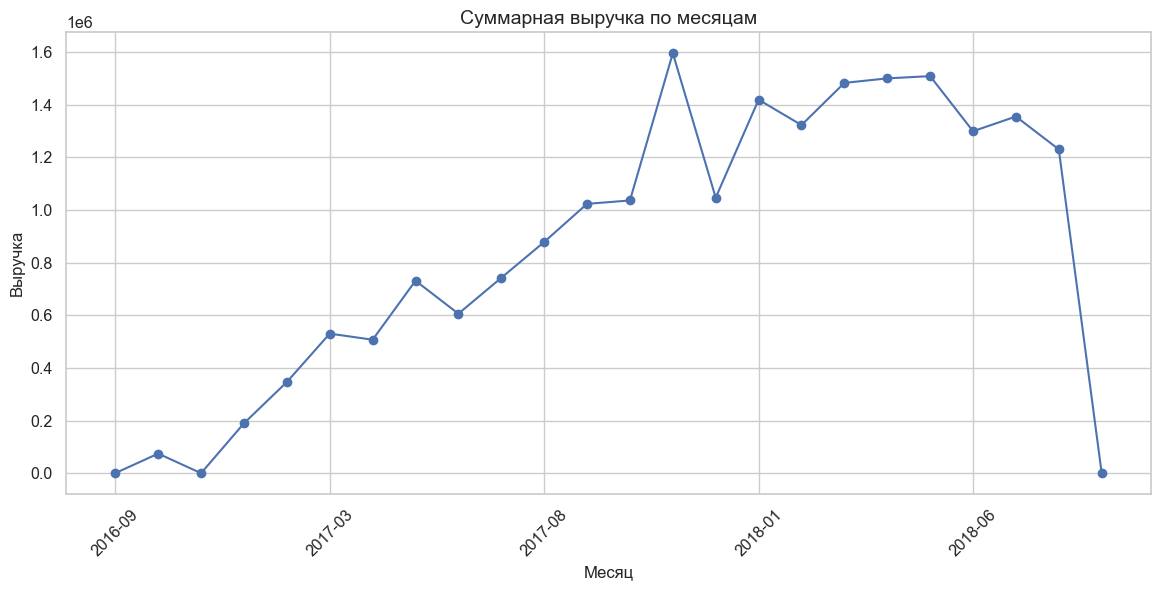

In [96]:
revenue_by_month = (
    df.groupby("purchase_month")["payment_value"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(14, 6))
revenue_by_month.plot(marker="o")
plt.title("Суммарная выручка по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Выручка")
plt.xticks(rotation=45)
plt.show()

### Видимо данные пользователей платформы собирались с самого открытия маркетплейса, в начале временного ряда околонулевые значения по кол-ву заказов. Последняя точка на графике скорее всего посчитана за неполный месяц

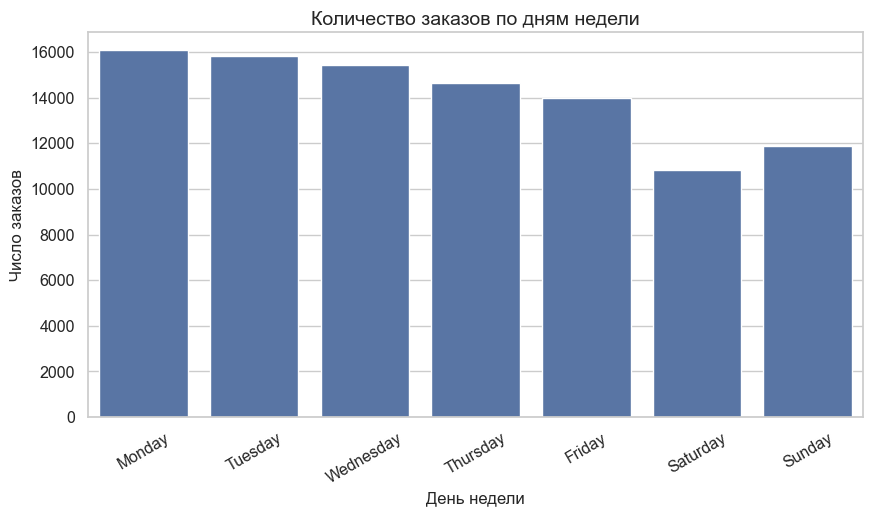

In [132]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

orders_by_dow = (
    df.groupby("purchase_dayofweek")["order_id"]
      .nunique()
      .reindex(dow_order)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=orders_by_dow.index, y=orders_by_dow.values)
plt.title("Количество заказов по дням недели")
plt.xlabel("День недели")
plt.ylabel("Число заказов")
plt.xticks(rotation=30)
plt.show()

### Здесь нехарактерый паттерн покупок у населения бразилии (а может и характерный для всех стран), в будние дни больше заказов, чем в выходные, видимо пока сидят на работе, выбирают товары

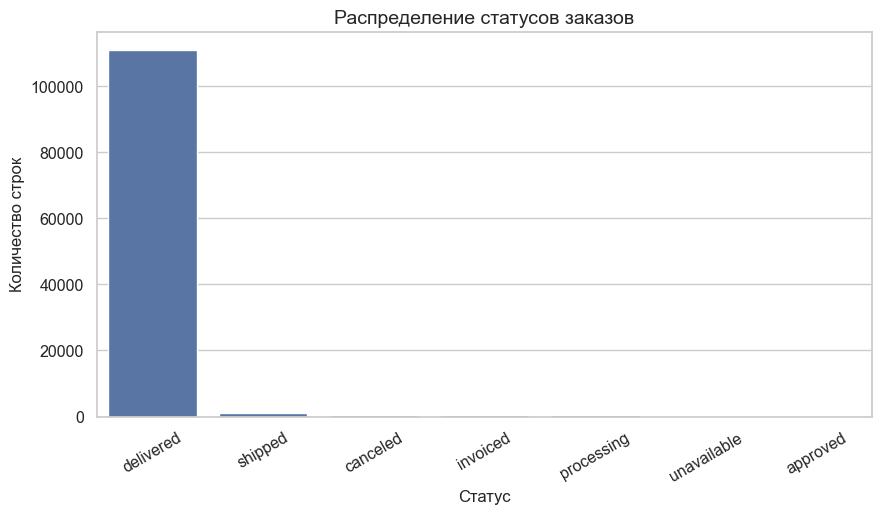

In [98]:
status_counts = df["order_status"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title("Распределение статусов заказов")
plt.xlabel("Статус")
plt.ylabel("Количество строк")
plt.xticks(rotation=30)
plt.show()

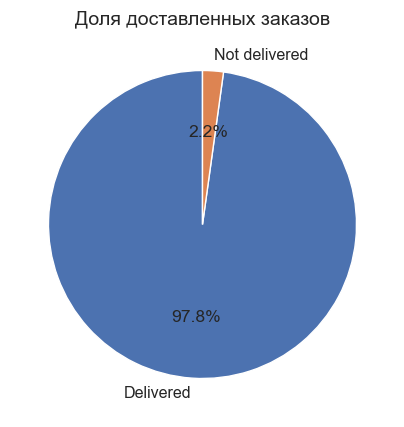

In [99]:
delivered_share = df["is_delivered"].mean()

plt.figure(figsize=(5, 5))
plt.pie(
    [delivered_share, 1 - delivered_share],
    labels=["Delivered", "Not delivered"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Доля доставленных заказов")
plt.show()

### В целом, доставка нормально работает, почти 98% заказов доставлены до покупателя. Хотя есть к чему стремиться, 2% на таких масштабах играют большую роль в становлении платформы и выстраивания доверия к доставке

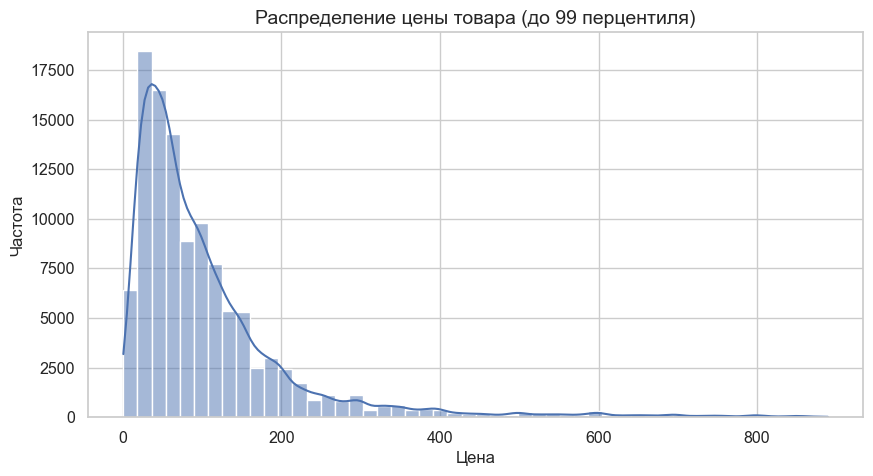

In [136]:
plt.figure(figsize=(10, 5))
sns.histplot(df.loc[df["price"] < df["price"].quantile(0.99), "price"], bins=50, kde=True)
plt.title("Распределение цены товара (до 99 перцентиля)")
plt.xlabel("Цена")
plt.ylabel("Частота")
plt.show()

### Цена товара имеет сильно скошенное распределение, большинство покупок сосредоточено в низком и среднем ценовом диапазоне, а дорогие товары встречаются редко. Это типично для массового e-commerce

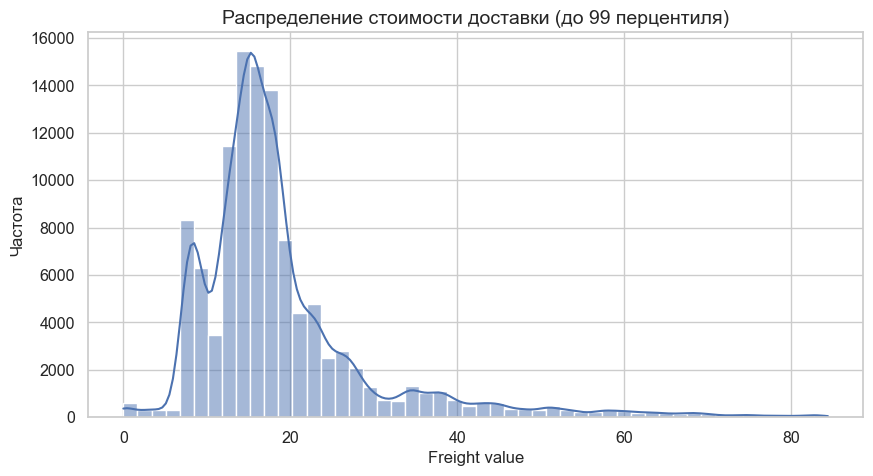

In [101]:
plt.figure(figsize=(10, 5))
sns.histplot(df.loc[df["freight_value"] < df["freight_value"].quantile(0.99), "freight_value"], bins=50, kde=True)
plt.title("Распределение стоимости доставки (до 99 перцентиля)")
plt.xlabel("Freight value")
plt.ylabel("Частота")
plt.show()

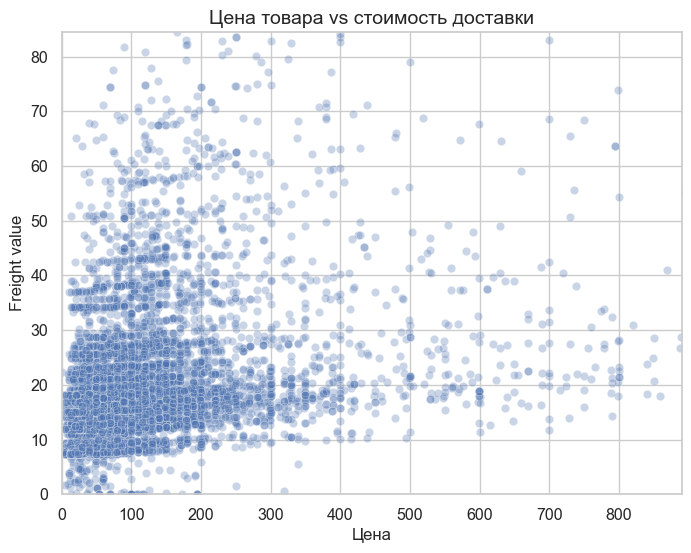

In [138]:
sample_df = df.sample(min(10000, len(df)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_df,
    x="price",
    y="freight_value",
    alpha=0.3
)
plt.xlim(0, df["price"].quantile(0.99))
plt.ylim(0, df["freight_value"].quantile(0.99))
plt.title("Цена товара vs стоимость доставки")
plt.xlabel("Цена")
plt.ylabel("Freight value")
plt.show()

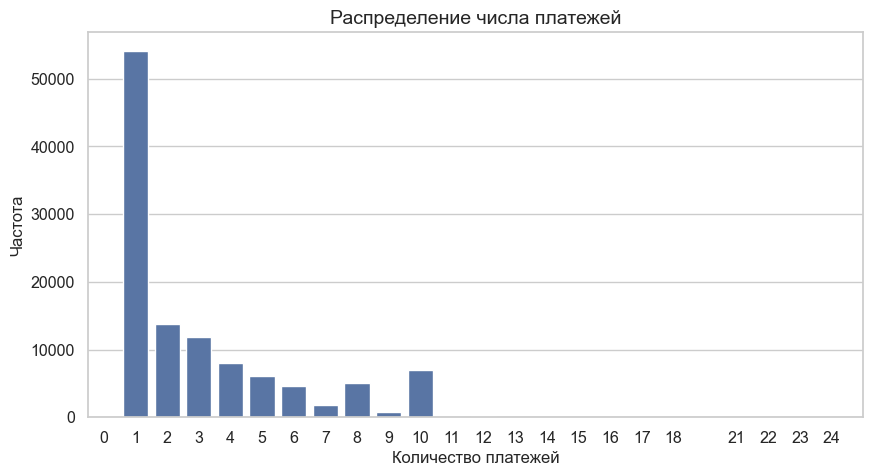

In [140]:
installments = df["payment_installments"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=installments.index.astype(int), y=installments.values)

plt.title("Распределение числа платежей")
plt.xlabel("Количество платежей")
plt.ylabel("Частота")
plt.xticks(installments.index.astype(int))

plt.show()

### Число платежей резко сконцентрировано на 1 платеже, но заметная доля клиентов использует 2–8 платежей

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(
    df.loc[df["delivery_time"].between(0, df["delivery_time"].quantile(0.99)), "delivery_time"],
    bins=50,
    kde=True
)
plt.title("Распределение времени доставки")
plt.xlabel("Дни")
plt.ylabel("Частота")
plt.show()

### У распределения времени доставки длинный правый хвост, часть заказов шла значительно дольше

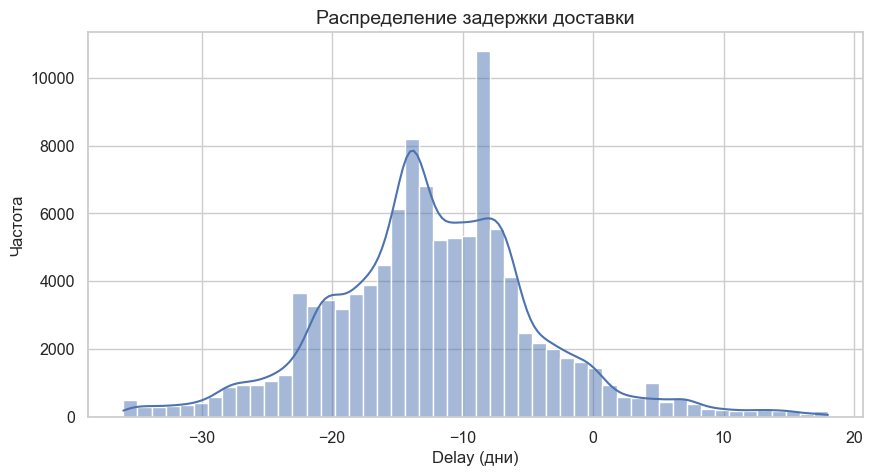

In [105]:
plt.figure(figsize=(10, 5))
sns.histplot(
    df.loc[df["delay"].between(df["delay"].quantile(0.01), df["delay"].quantile(0.99)), "delay"],
    bins=50,
    kde=True
)
plt.title("Распределение задержки доставки")
plt.xlabel("Delay (дни)")
plt.ylabel("Частота")
plt.show()

### Распределение задержки доставки в основном находится в отрицательной зоне, то есть большинство заказов было доставлено раньше обещанного срока. Возможно оценка доставки изначально была консервативной, чтобы не обнадеживать покупателей. 

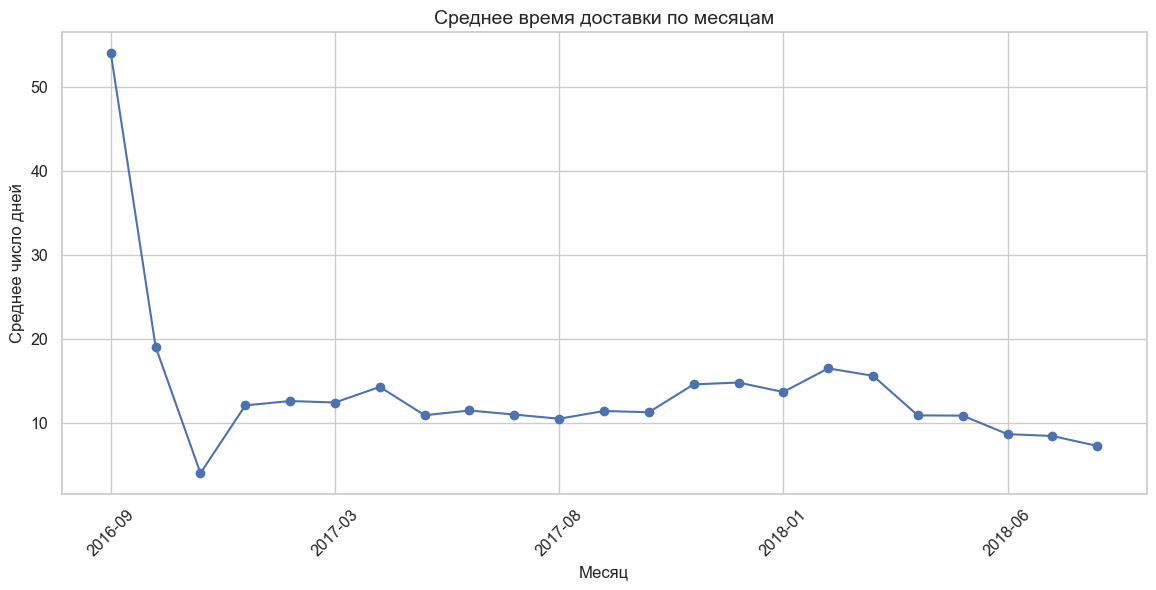

In [107]:
delivery_by_month = (
    df.groupby("purchase_month")["delivery_time"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(14, 6))
delivery_by_month.plot(marker="o")
plt.title("Среднее время доставки по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Среднее число дней")
plt.xticks(rotation=45)
plt.show()

### По началу, средний срок доставки был анамально большим, возможно из за настраивания логистики или из за нехватки данных. Со временем этот показатель стабилизировался, а с июня 2018 года даже снижался, возможно из за улучшения операционной эффективности

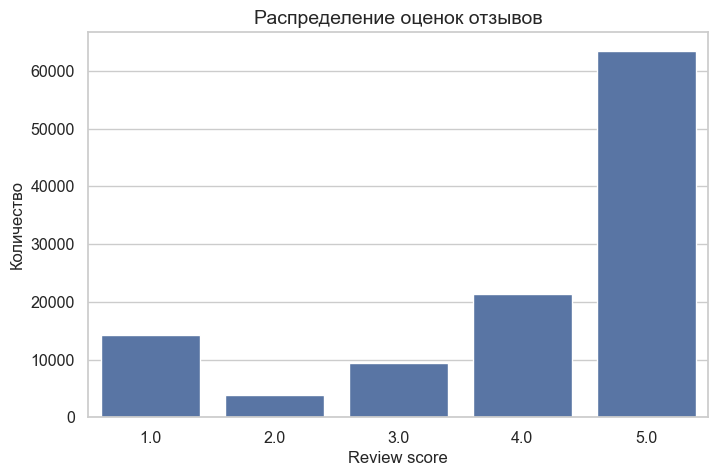

In [153]:
review_counts = df["review_score"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=review_counts.index, y=review_counts.values)
plt.title("Распределение оценок отзывов")
plt.xlabel("Review score")
plt.ylabel("Количество")
plt.show()

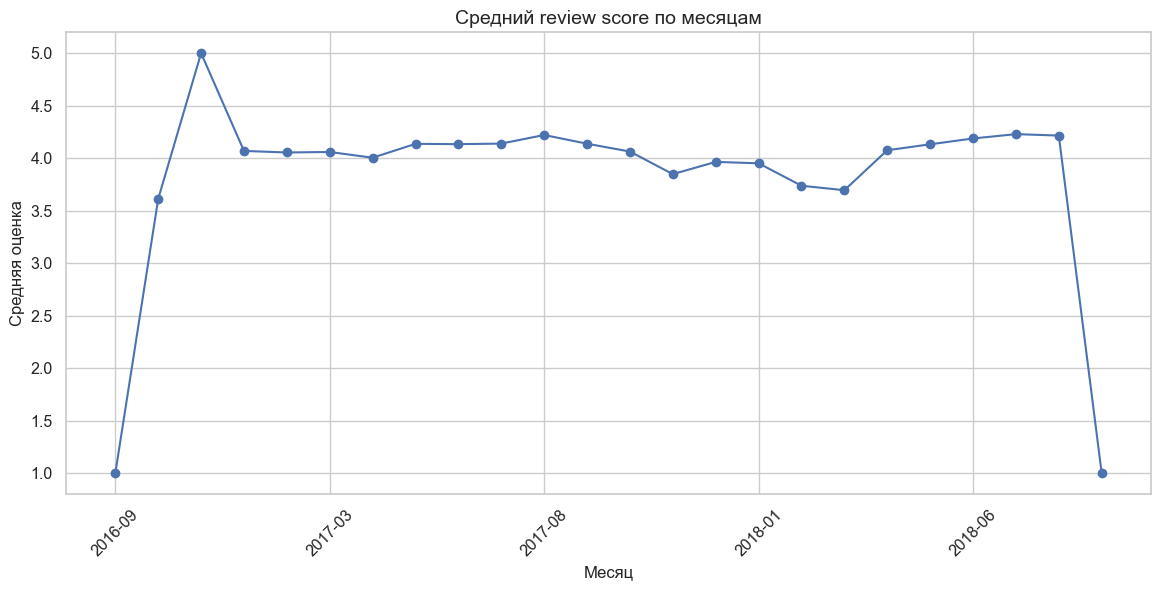

In [109]:
review_by_month = (
    df.groupby("purchase_month")["review_score"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(14, 6))
review_by_month.plot(marker="o")
plt.title("Средний review score по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средняя оценка")
plt.xticks(rotation=45)
plt.show()

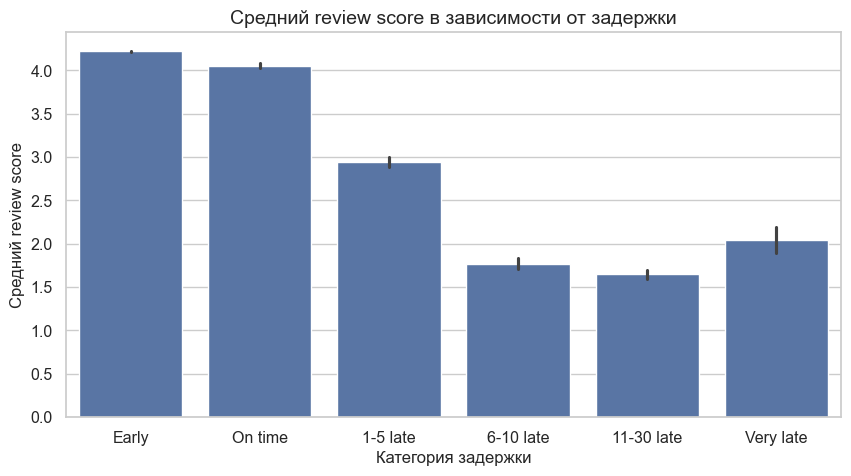

In [155]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=temp,
    x="delay_bucket",
    y="review_score",
    errorbar="ci"
)

plt.title("Средний review score в зависимости от задержки")
plt.xlabel("Категория задержки")
plt.ylabel("Средний review score")

plt.show()

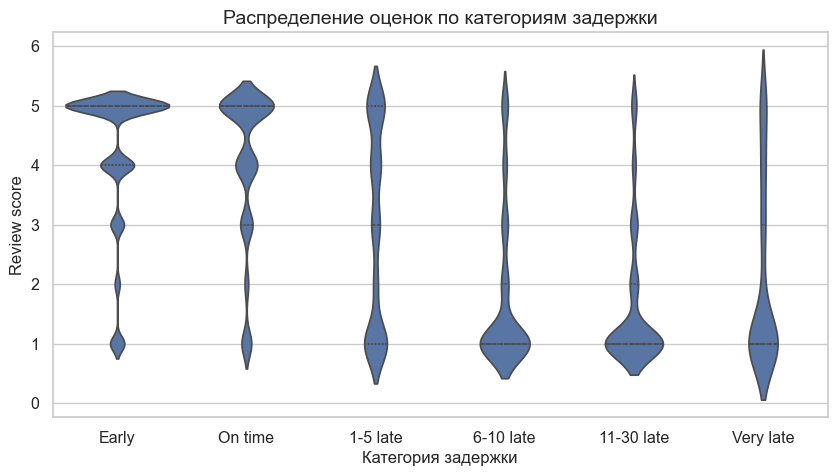

In [156]:
plt.figure(figsize=(10, 5))

sns.violinplot(
    data=temp,
    x="delay_bucket",
    y="review_score",
    inner="quartile"
)

plt.title("Распределение оценок по категориям задержки")
plt.xlabel("Категория задержки")
plt.ylabel("Review score")

plt.show()

### Задержка доставки очень заметно влияет на оценку, если заказ приходит раньше или вовремя, средний review score около 4+, а при задержке на 6 дней и более средняя оценка резко падает почти до 1.5–2.0

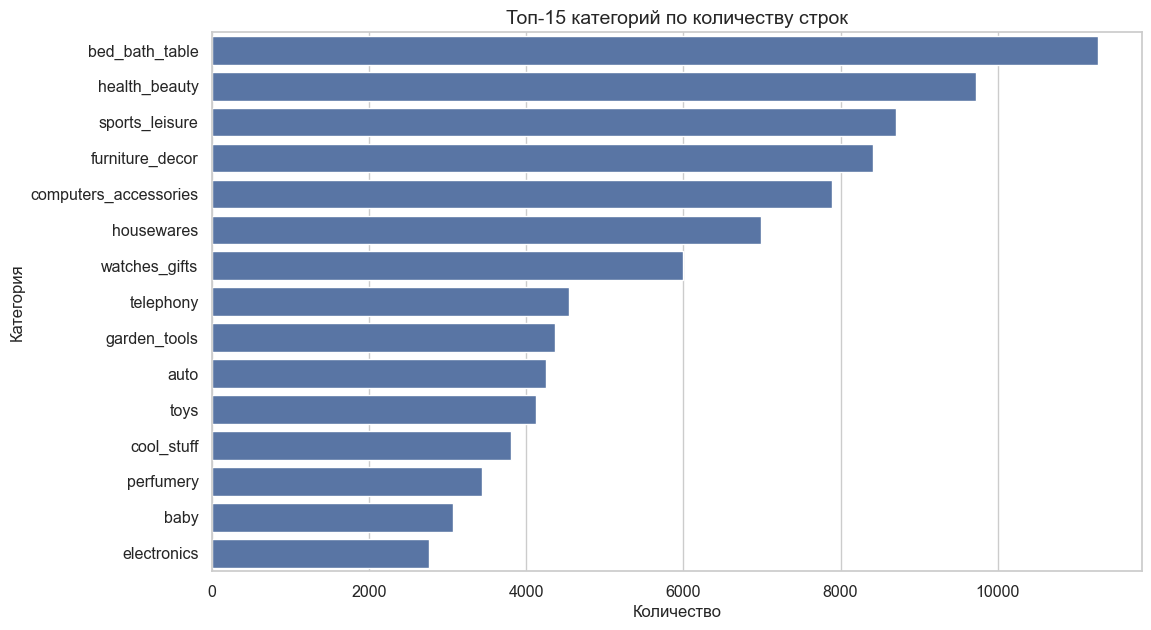

In [112]:
top_cat_count = df["category"].value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_cat_count.values, y=top_cat_count.index)
plt.title("Топ-15 категорий по количеству строк")
plt.xlabel("Количество")
plt.ylabel("Категория")
plt.show()

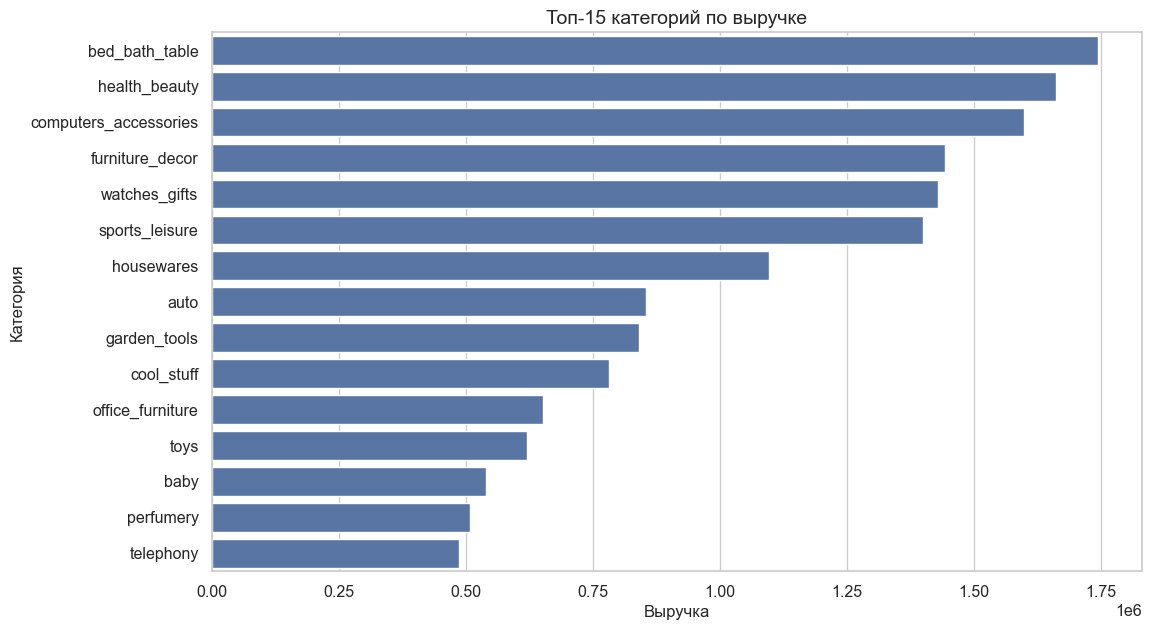

In [113]:
top_cat_revenue = (
    df.groupby("category")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_cat_revenue.values, y=top_cat_revenue.index)
plt.title("Топ-15 категорий по выручке")
plt.xlabel("Выручка")
plt.ylabel("Категория")
plt.show()

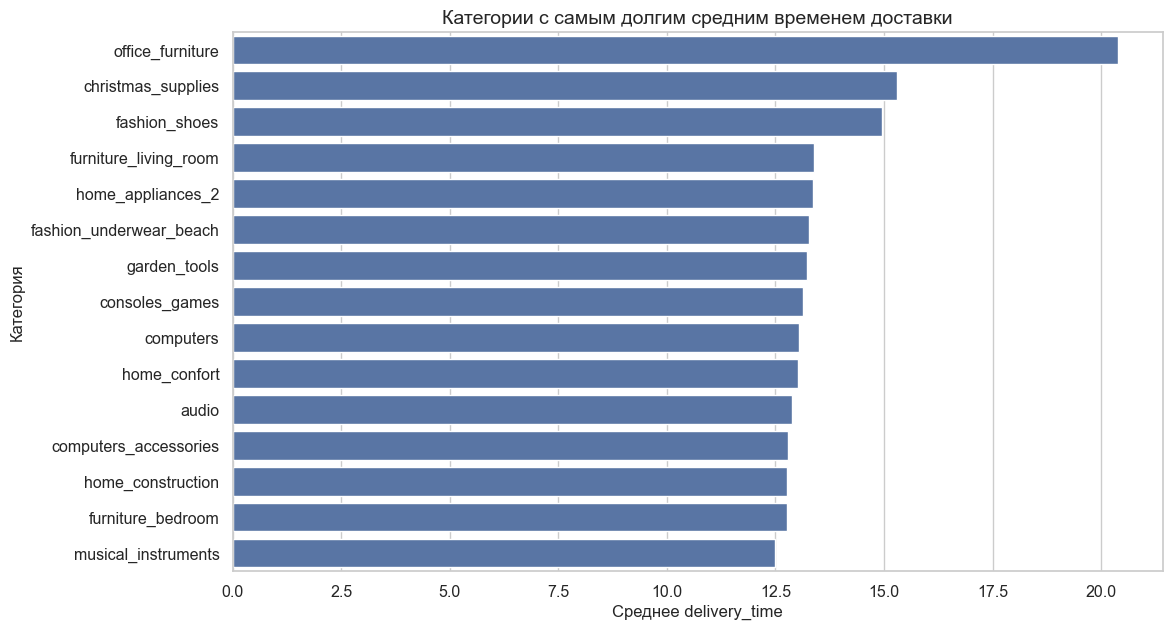

In [115]:
cat_delivery = (
    df.groupby("category")
      .agg(mean_delivery=("delivery_time", "mean"),
           n=("delivery_time", "count"))
)

cat_delivery = cat_delivery[cat_delivery["n"] >= 100].sort_values("mean_delivery", ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=cat_delivery["mean_delivery"], y=cat_delivery.index)
plt.title("Категории с самым долгим средним временем доставки")
plt.xlabel("Среднее delivery_time")
plt.ylabel("Категория")
plt.show()

### Категории с самым долгим средним временем доставки в значительной степени связаны с мебелью, интерьером, бытовой техникой и крупными товарами

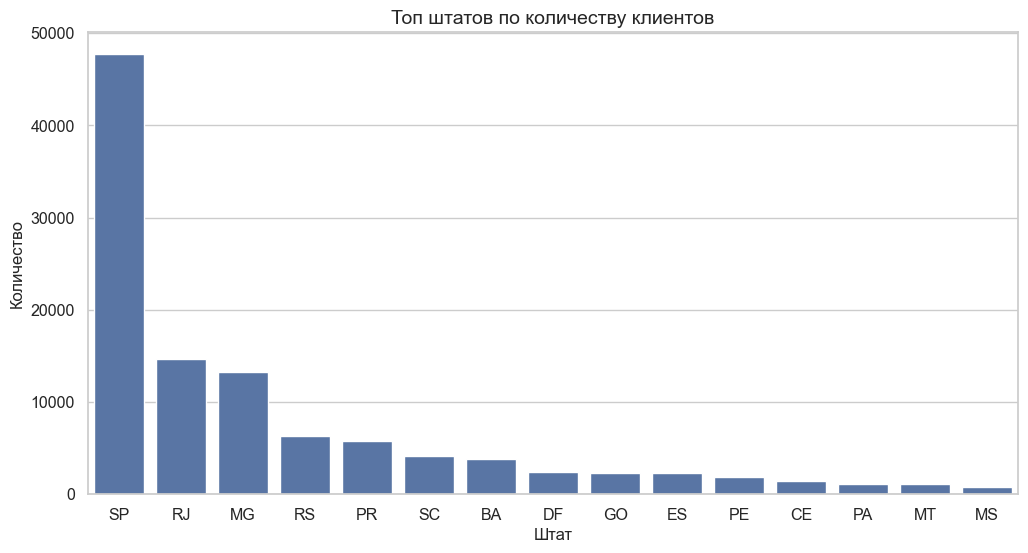

In [116]:
top_states = df["customer_state"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_states.index, y=top_states.values)
plt.title("Топ штатов по количеству клиентов")
plt.xlabel("Штат")
plt.ylabel("Количество")
plt.show()

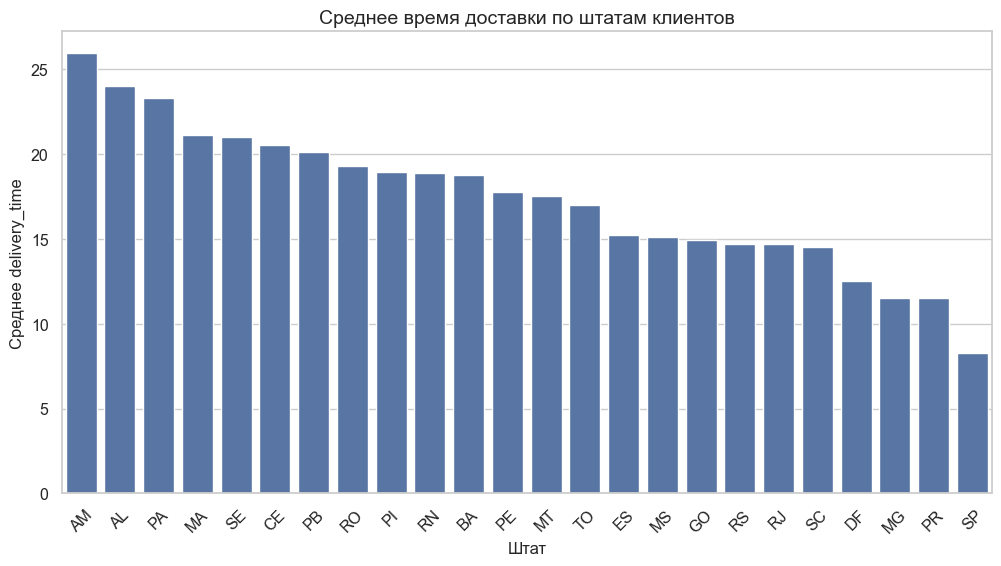

In [118]:
state_delivery = (
    df.groupby("customer_state")
      .agg(mean_delivery=("delivery_time", "mean"),
           n=("delivery_time", "count"))
)

state_delivery = state_delivery[state_delivery["n"] >= 100].sort_values("mean_delivery", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_delivery.index, y=state_delivery["mean_delivery"])
plt.title("Среднее время доставки по штатам клиентов")
plt.xlabel("Штат")
plt.ylabel("Среднее delivery_time")
plt.xticks(rotation=45)
plt.show()

### Клиентская база очень сильно сконцентрирована в штате SP (Сан Пауло). Значит, спрос распределён неравномерно и бизнес сильно опирается на крупнейшие урбанизированные регионы. По времени доставки Сан Пауло ожидаемо, показывает лучшие результаты

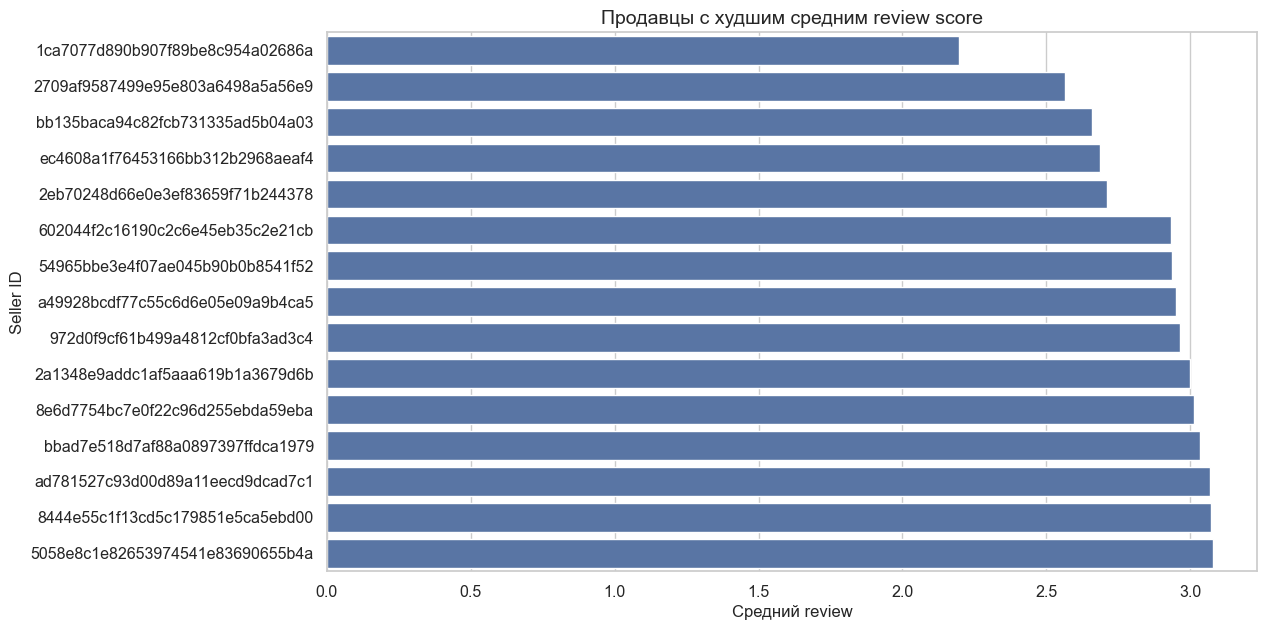

In [120]:
seller_review = (
    df.groupby("seller_id")
      .agg(mean_review=("review_score", "mean"),
           n=("review_score", "count"))
)

seller_review = seller_review[seller_review["n"] >= 30].sort_values("mean_review").head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=seller_review["mean_review"], y=seller_review.index)
plt.title("Продавцы с худшим средним review score")
plt.xlabel("Средний review")
plt.ylabel("Seller ID")
plt.show()

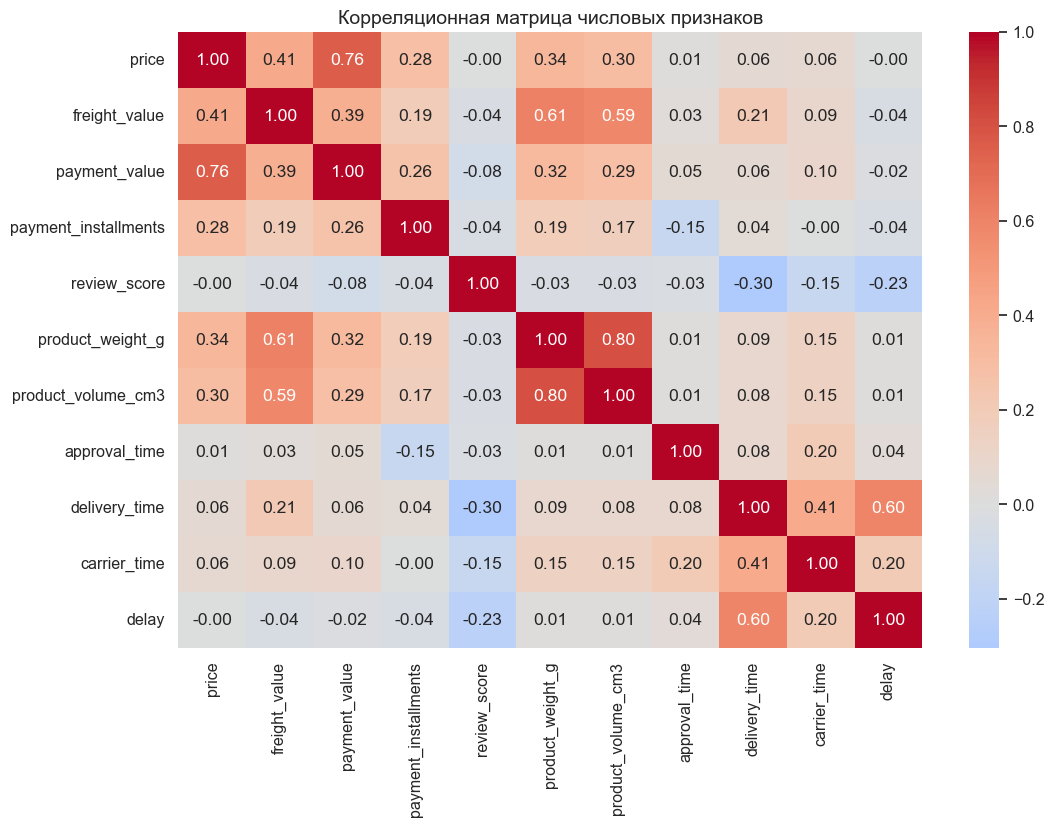

In [121]:
num_cols = [
    "price", "freight_value", "payment_value", "payment_installments",
    "review_score", "product_weight_g", "product_volume_cm3",
    "approval_time", "delivery_time", "carrier_time", "delay"
]

corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

### Здесь неожиданных результатов нет. Наиболее сильная связь — между price и payment_value (0.76), что естественн, чем выше цена товара, тем выше итоговая сумма заказа. freight_value заметно связан с весом и объёмом товара (0.61 и 0.59) что тоже логично. В подтверждение увиденному ранее, review_score отрицательно коррелирует с delivery_time (-0.30) и delay (-0.23). Но review_score не связан совсем с ценой товара, обычно в отзывах (по своему опыту) видишь, что у людей больше ожидания от товара с большим ценником

In [123]:
order_df = (
    df.groupby("order_id")
      .agg(
          purchase_time=("order_purchase_timestamp", "min"),
          customer_state=("customer_state", "first"),
          order_status=("order_status", "first"),
          review_score=("review_score", "mean"),
          payment_value=("payment_value", "max"),
          items_count=("order_item_id", "count"),
          total_freight=("freight_value", "sum"),
          total_price=("price", "sum"),
          delivery_time=("delivery_time", "mean"),
          delay=("delay", "mean"),
      )
      .reset_index()
)

order_df["purchase_month"] = order_df["purchase_time"].dt.to_period("M").astype(str)

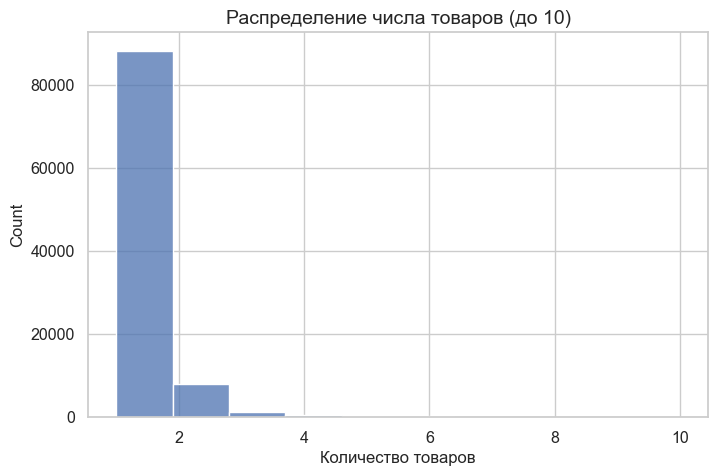

In [158]:
plt.figure(figsize=(8, 5))

sns.histplot(
    order_df.loc[order_df["items_count"] <= 10, "items_count"],
    bins=10
)

plt.title("Распределение числа товаров (до 10)")
plt.xlabel("Количество товаров")

plt.show()

### Абсолютное большинство заказов содержит один товар

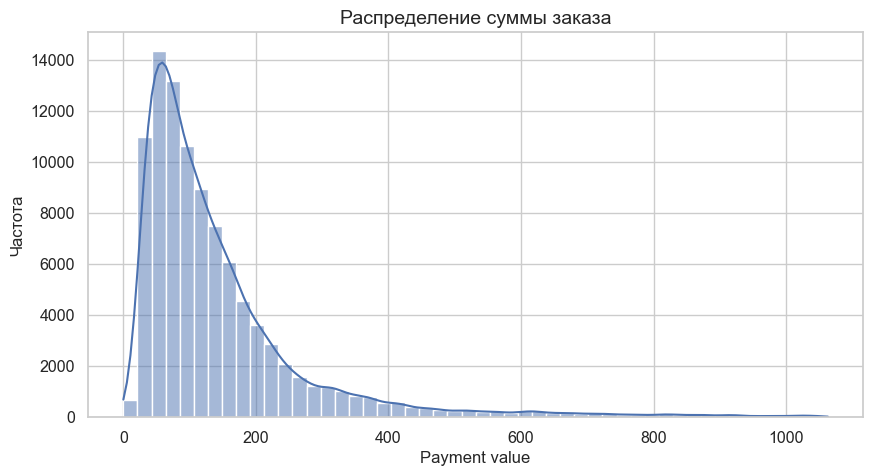

In [125]:
plt.figure(figsize=(10, 5))
sns.histplot(
    order_df.loc[order_df["payment_value"] < order_df["payment_value"].quantile(0.99), "payment_value"],
    bins=50,
    kde=True
)
plt.title("Распределение суммы заказа")
plt.xlabel("Payment value")
plt.ylabel("Частота")
plt.show()

### Распределение суммы заказа тоже сильно скошено вправо, большинство заказов сосредоточено в низком и среднем ценовом диапазоне

# Выводы по датасету
- Клиенты в целом довольны сервисом, но плохая логистика резко увеличивает вероятность низких оценок.
- Своевременная доставка — один из ключевых факторов высокого review score.
- Ядро бизнеса сосредоточено в нескольких крупных категориях, прежде всего в товарах для дома, красоты, спорта и аксессуарах.
- Крупные и сложные товары доставляются дольше, что создаёт риск ухудшения клиентского опыта именно в этих категориях.
- Основной рынок платформы — São Paulo, и именно там логистика работает лучше всего.
- Стоимость доставки определяется в первую очередь весом и объёмом товара, а не его ценой.
- Большинство заказов — однотоварные и с относительно небольшим чеком, что отражает массовый характер потребления на платформе.